In [51]:
from google.cloud import bigquery

PROJECT = "gridzero-489711"
DATASET = "merged_set"
TABLE = "full_feature_engineered_data_test"

query = f"""
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
"""

client = bigquery.Client('gridzero-489711')
query_job = client.query(query)
result = query_job.result()
df = result.to_dataframe()

/Users/jamesla/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [52]:
df.head()

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [53]:
import pandas as pd
import numpy as np

# features to use
feature_cols = [
    'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms',
    'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2',
    'diffuse_radiation_wm2', 'pressure_msl_hpa', 'precipitation_mm',
    'biomass', 'fossil_gas', 'fossil_hard_coal',
    'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'nuclear',
    'other', 'solar', 'wind_offshore', 'wind_onshore',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'doy_sin', 'doy_cos', 'carbon_lag_48', 'carbon_lag_336', 'carbon_lag_17520'
]

X = df_model[feature_cols]
y = df_model['carbon_intensity_gco2_kwh']

In [54]:
# X['gas_share'] = df_model['fossil_gas'] / df_model['totaloutput_mw']
# X['wind_share'] = (df_model['wind_onshore'] + df_model['wind_offshore']) / df_model['totaloutput_mw']
# X['solar_share'] = df_model['solar'] / df_model['totaloutput_mw']

In [55]:
# split = int(len(df_model) * 0.8)

# X_train = X.iloc[:split]
# X_test = X.iloc[split:]

# y_train = y.iloc[:split]
# y_test = y.iloc[split:]

In [56]:
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Grid Search

In [57]:
# param_grid = {
#     "max_depth": [4,5,6,7,8],
#     "learning_rate": [0.01,0.02,0.03,0.05],
#     "n_estimators": [400,600,800,1000],
#     "min_child_weight": [1,3,5,7],
#     "subsample": [0.7,0.8,0.9],
#     "colsample_bytree": [0.7,0.8,0.9],
#     "gamma": [0,0.1,0.2],
#     "reg_alpha": [0,0.1,0.5],
#     "reg_lambda": [1,2,5]
# }

In [58]:
# from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(
#     n_splits=5,
#     gap=48
# )

In [59]:
# from sklearn.model_selection import RandomizedSearchCV

# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_grid,
#     n_iter=100,                 # number of parameter samples
#     cv=tscv,
#     scoring="neg_root_mean_squared_error",
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)

# print("Best params:", random_search.best_params_)
# print("Best score:", -random_search.best_score_)

# Model Training

In [60]:
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.02,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "reg_alpha": 0.1,
    "reg_lambda": 2,
}

In [61]:
evals = [(dtrain, "train"), (dtest, "eval")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,  # stop if eval metric does not improve for 50 rounds
    verbose_eval=True
)

[0]	train-rmse:68.11593	eval-rmse:73.35569
[1]	train-rmse:66.95737	eval-rmse:72.06931
[2]	train-rmse:66.01373	eval-rmse:70.96568
[3]	train-rmse:64.88899	eval-rmse:69.69403
[4]	train-rmse:63.81382	eval-rmse:68.47701
[5]	train-rmse:62.92539	eval-rmse:67.42239
[6]	train-rmse:61.88481	eval-rmse:66.24007
[7]	train-rmse:60.84744	eval-rmse:65.09947
[8]	train-rmse:59.85863	eval-rmse:63.98906
[9]	train-rmse:58.86236	eval-rmse:62.89706
[10]	train-rmse:57.91089	eval-rmse:61.82376
[11]	train-rmse:56.95890	eval-rmse:60.78834
[12]	train-rmse:56.17571	eval-rmse:59.86601
[13]	train-rmse:55.26187	eval-rmse:58.86046
[14]	train-rmse:54.38202	eval-rmse:57.85596
[15]	train-rmse:53.52223	eval-rmse:56.88488
[16]	train-rmse:52.79561	eval-rmse:56.17679
[17]	train-rmse:51.94876	eval-rmse:55.23174
[18]	train-rmse:51.12231	eval-rmse:54.31777
[19]	train-rmse:50.31612	eval-rmse:53.43215
[20]	train-rmse:49.67831	eval-rmse:52.81544
[21]	train-rmse:48.89406	eval-rmse:51.92624
[22]	train-rmse:48.29523	eval-rmse:51.3200

In [62]:
# from xgboost import XGBRegressor

# model = XGBRegressor(
#     objective="reg:squarederror",
#     n_estimators=1000,
#     learning_rate=0.02,
#     max_depth=6,
#     min_child_weight=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     gamma=0.1,
#     reg_alpha=0.1,
#     reg_lambda=2,
#     random_state=42,
#     n_jobs=-1
# )

In [66]:
model.save_model("model.json")

In [68]:
from google.cloud import storage

def upload_to_gcs(bucket_name, source_file, destination_blob):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(destination_blob)

    blob.upload_from_filename(source_file)
    print(f"Uploaded {source_file} to gs://{bucket_name}/{destination_blob}")

upload_to_gcs(
    bucket_name="grid_zero_bucket",
    source_file="model.json",
    destination_blob="xgboost_model1"
)

Uploaded model.json to gs://grid_zero_bucket/xgboost_model1


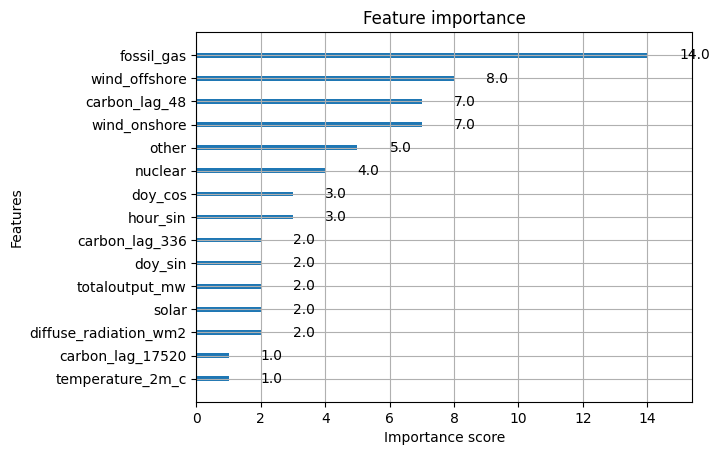

In [65]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=15)
plt.show()